In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=32
paradigm = P300(resample=sfreq, tmin=-0.2, tmax=1, fmin=0.1, fmax=fmax)
dataset = EPFLP300()
subject, session, run = 1, "session_1", "run_1"
#dataset = BNCI2014009()
#subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
137 matching events found
No baseline correction applied


Number of events,137
Events,NonTarget: 114Target: 23
Time range,-0.188 – 0.969 sec
Baseline,off


Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


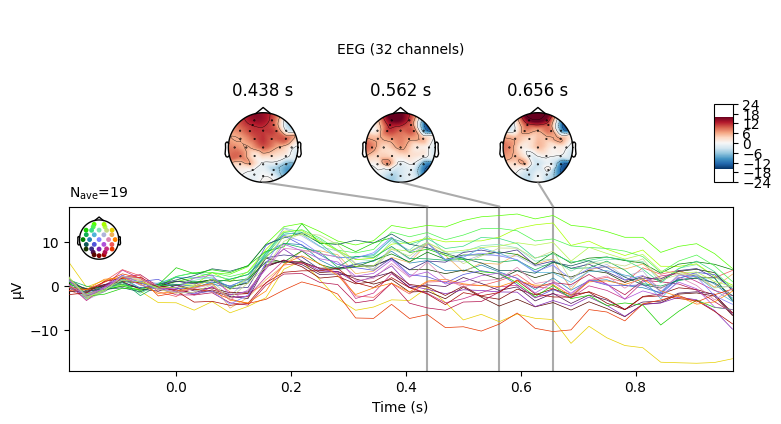

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('cupy')

X_train = tl.tensor(epochs_train.get_data().astype(np.float32))
y_train = labels_train
X_test = tl.tensor(epochs_test.get_data().astype(np.float32))
y_test = labels_test

X_train /= np.std(X_train, axis=0)[np.newaxis,:,:]
X_test /= np.std(X_train, axis=0)[np.newaxis,:,:]

In [8]:
hoda = HODA(
    max_iter=128,
    rank=(3,3),
    tol=1e-6,
    init ='svd',
    verbose=True,
    shrinkage=('oas', 'oas'),
    toeplitz=(1,),
    solver='ratio_svd'
)
#%lprun -f  hoda.fit hoda.fit(X_train,y_train)
hoda.fit(X_train,y_train)


100%|███████████████████████████████████████████████████████████████████████████████| 128/128 [00:01<00:00, 65.06it/s]


HODA(init='svd', max_iter=128, rank=(3, 3), shrinkage=('oas', 'oas'),
     solver='ratio_svd', toeplitz=(1,), tol=1e-06, verbose=True)

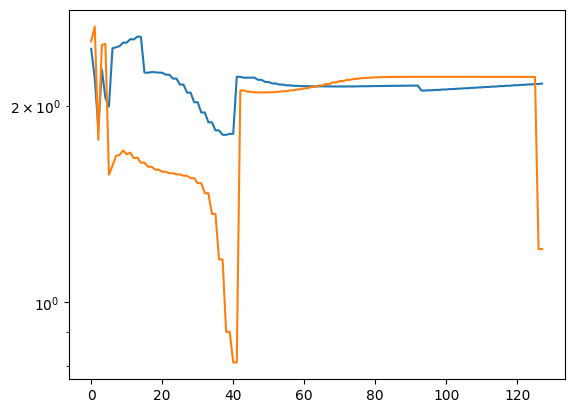

In [9]:
import cupy

plt.semilogy(cupy.asnumpy(hoda.updates_[:,:hoda.iter_]))
plt.show()

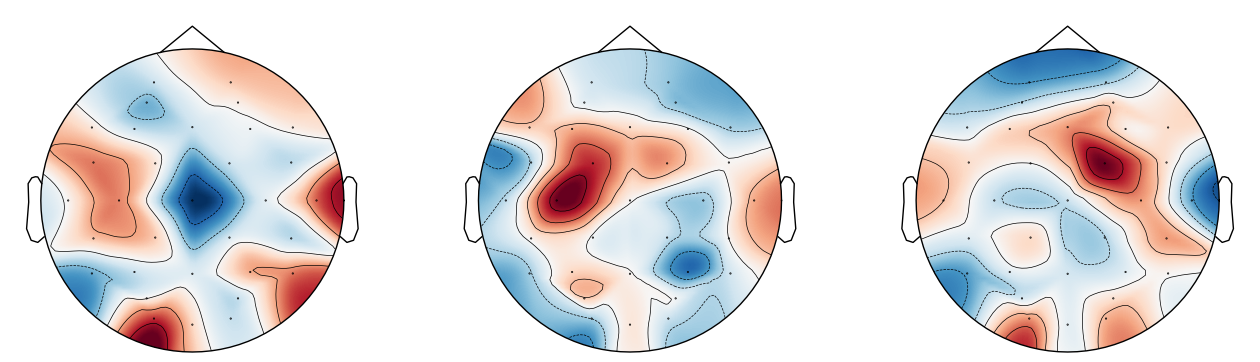

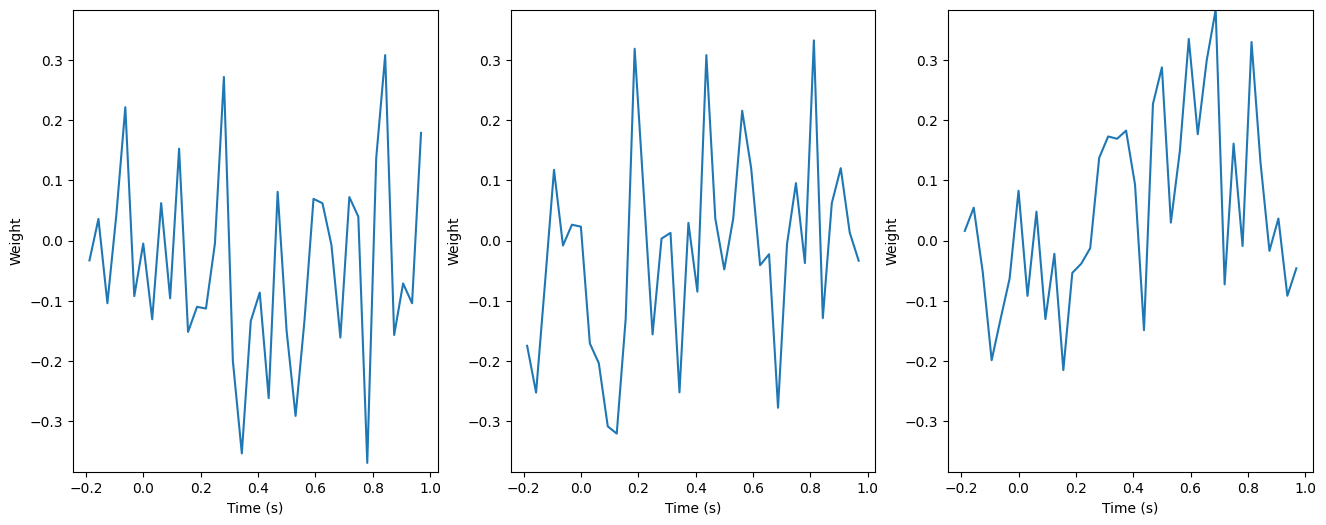

In [10]:
fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(hoda.projs_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(hoda.projs_[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(hoda.projs_[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])


No projector specified for this dataset. Please consider the method self.add_proj.


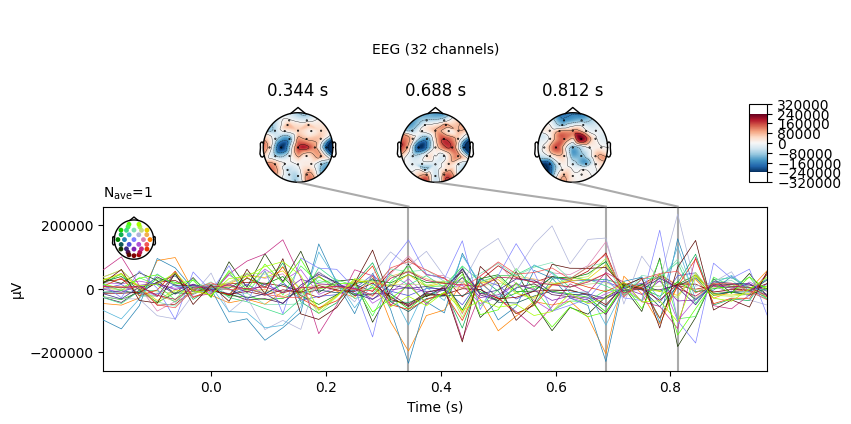

In [11]:
from mne import EvokedArray

w_sp = hoda.projs_[0].squeeze()
w_tmp = hoda.projs_[1].squeeze()
w = cupy.asnumpy(w_sp @ w_tmp.T)
w = EvokedArray(w, epochs.info, epochs.tmin)
_ = w.plot_joint()

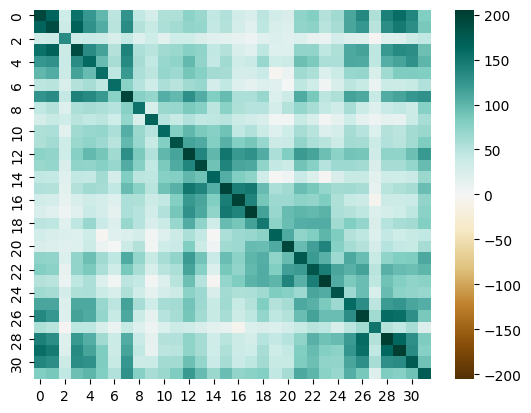

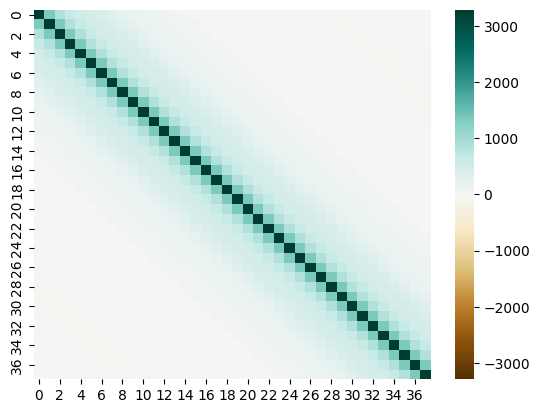

In [12]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

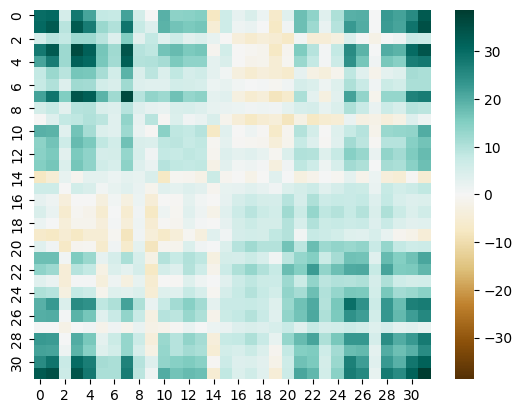

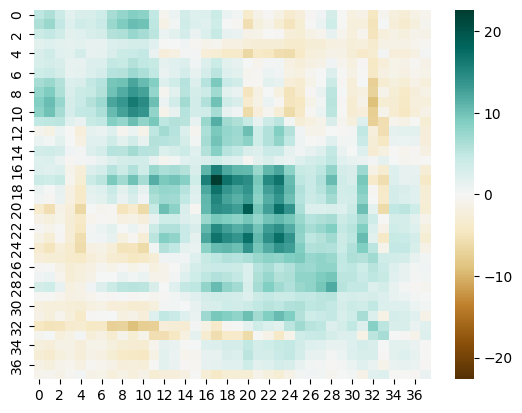

In [13]:
for k in range(2):
    cov = cupy.asnumpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax)
    plt.show()

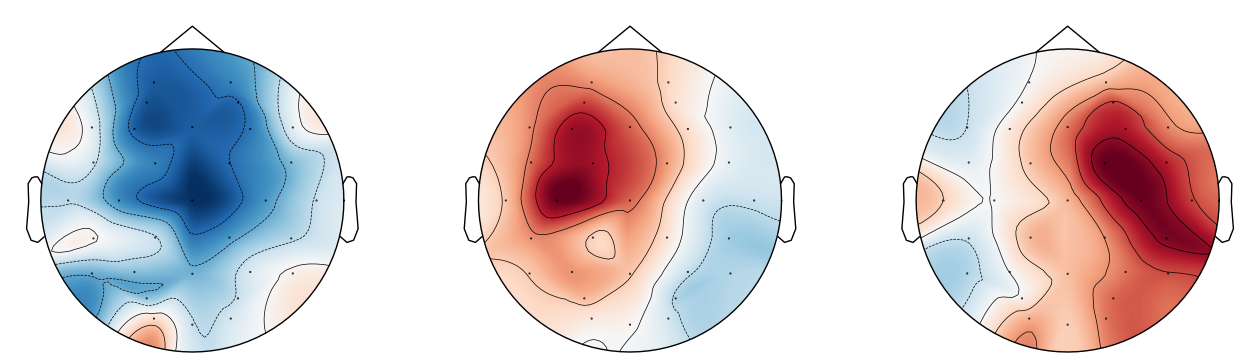

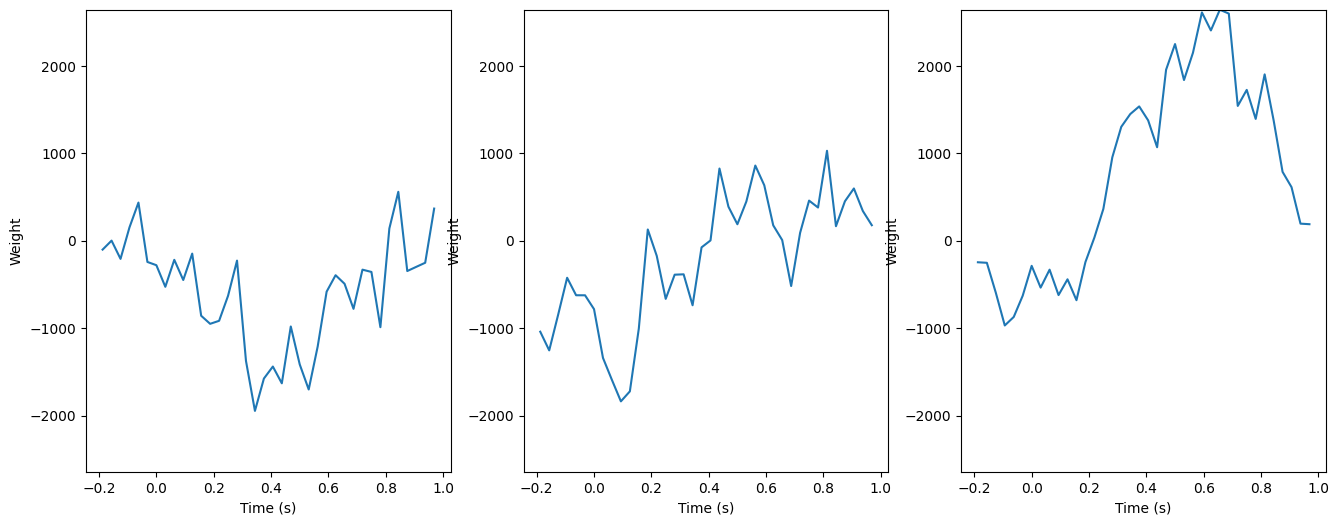

In [14]:
patterns = [hoda.scatter_w_[k] @ p for k,p in enumerate(hoda.projs_)]

fig, axs = plt.subplots(1,hoda.rank_[0], figsize=(16,6))
for i in range(hoda.rank_[0]):
    w = cupy.asnumpy(patterns[0][:,i])
    plot_topomap(w, epochs.info, axes=axs[i], show=False)
vmax = np.max(np.abs(patterns[1]))
fig, axs = plt.subplots(1,hoda.rank_[1], figsize=(16,6))
for i in range(hoda.rank_[1]):
    w = cupy.asnumpy(patterns[1][:,i])
    axs[i].plot(epochs.times, w)
    axs[i].set_xlabel('Time (s)')
    axs[i].set_ylabel('Weight')
    axs[i].set_ylim([-vmax, vmax])

Applying baseline correction (mode: mean)
No projector specified for this dataset. Please consider the method self.add_proj.


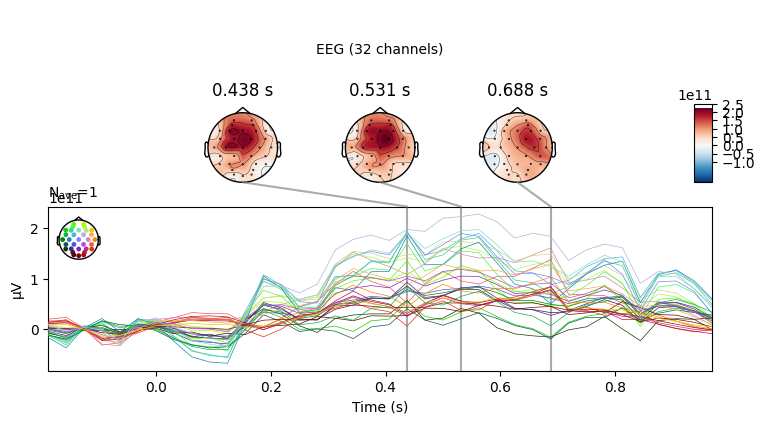

In [15]:
w_sp = hoda.projs_[0].squeeze()
w_tmp = hoda.projs_[1].squeeze()
ap_sp = hoda.scatter_w_[0] @ w_sp
ap_tmp = hoda.scatter_w_[1] @ w_tmp
ap = cupy.asnumpy(ap_sp @ ap_tmp.T)
ap = EvokedArray(ap, epochs.info, epochs.tmin)
ap.apply_baseline((-0.2, 0))
_ = ap.plot_joint()

In [16]:
Xt_train = cupy.asnumpy(hoda.transform(X_train))
Xt_test = cupy.asnumpy(hoda.transform(X_test))

Xt_train = Xt_train.reshape((Xt_train.shape[0],-1))
Xt_test = Xt_test.reshape((Xt_test.shape[0],-1))

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.svm import SVC

classifier = LDA(solver='lsqr', shrinkage='auto')

classifier.fit(Xt_train,y_train)


LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')

In [18]:
feature_order = np.argsort(-np.abs(classifier.coef_))[::-1].squeeze()
f1 = feature_order[0]
f2 = feature_order[1]

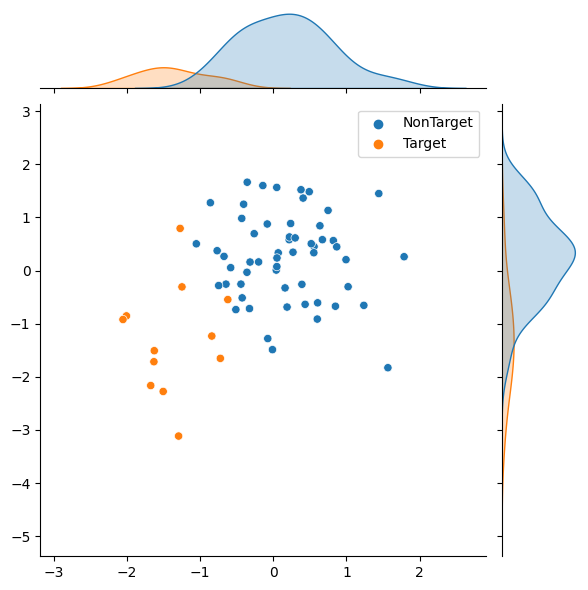

In [19]:
import seaborn as sns

g = sns.jointplot(x=Xt_train[:,f1],y=Xt_train[:,f2], hue=y_train)

In [20]:
roc_auc_score(y_train, classifier.predict_proba(Xt_train)[:,1])

1.0

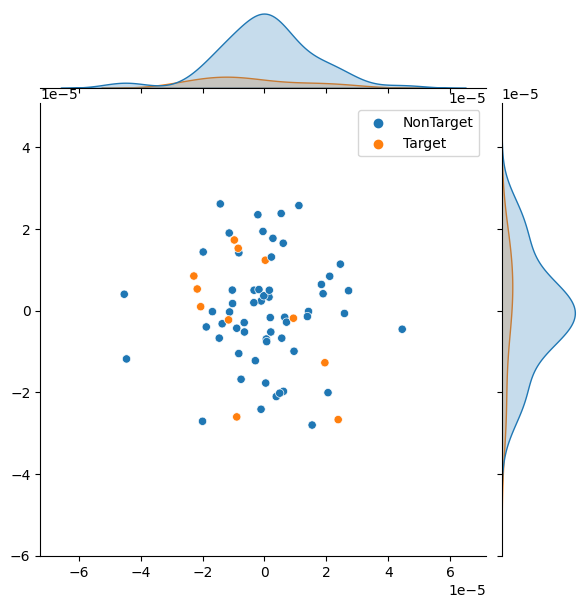

In [21]:
g = sns.jointplot(x=Xt_test[:,f1],y=Xt_test[:,f2], hue=y_test)

In [22]:
roc_auc_score(y_test, classifier.predict_proba(Xt_test)[:,1])

0.5203761755485893